# 1 Initialize the Database

All the code related to data management is in the `EnvironmentData` class. This makes life easier - for example: we can send the CatsUserID once and it becomes a class property. Then, when we call other operations we don't have to send this information again.

When you create a new instance of `EnvironmentData` and there is no database, it will pull historical data and initialize the database. 

In [1]:
# clear prior data. 
import os
import shutil
if os.path.exists('data'):
    shutil.rmtree('data')
    os.makedirs('data')

from EnvironmentData import EnvironmentData 
#envdt = EnvironmentData(CatsUserID = 2496, days_back = 365 * 2, out_of_scope = ['-80', 'Cryo tank', 'Water'], testing = True)
envdt = EnvironmentData(CatsUserID = 2496, out_of_scope = ['-80', 'Cryo tank', 'Water'])

Gather readings: SensorReadingRh: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 65/65 [04:08<00:00,  3.82s/it]


Detailed information is saved in the log:

In [2]:
# Detailed info is saved in the log.
with open('data/EnvironmentData.log', 'r') as file:
    for line in file.read().splitlines()[:10]:
        print(line)

2024-10-18 12:36:29,726 - EnvironmentData - INFO - initialize_database
2024-10-18 12:36:29,726 - EnvironmentData - INFO - get_sensors
2024-10-18 12:36:29,726 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/cats/user/?ApiKey=XXXX&CatsUserID=XXXX
2024-10-18 12:36:30,986 - EnvironmentData - INFO - get_sensors validation: correct column data types.
2024-10-18 12:36:30,986 - EnvironmentData - INFO - get_sensors validation: at least one non-null value in readings.
2024-10-18 12:36:30,987 - EnvironmentData - INFO - get_sensors validation: no duplicated SensorReadingUTC per SensorID_Coris.
2024-10-18 12:36:30,988 - EnvironmentData - INFO - get_sensors validation: one SensorName per SensorID_Coris.
2024-10-18 12:36:30,999 - EnvironmentData - INFO - API call: https://cats.corismonitoring.com/api/sensor/historical/?ApiKey=XXXX&SensorID=21373&ReadingType=SensorReadingF&StartUTC=1666204589&EndUTC=1729276589&MinReadingSpacing=600&RequestedOutputFormat=raw
2024-10-18 12:36:3

Raw data is now in the database in `data/sensor_readings.parquet`. 

Initially, we leave the data mostly as-is. We'll clean when moving to analytical steps, this preserves the source data so we can always change our mind about how we decide to view it. 

There are just a few columns because this is only historical data. We'll bring in current data shortly, and that will add more columns. 

In [3]:
import polars
polars.read_parquet('data/sensor_readings.parquet')

SensorReadingUTC,SensorReadingF,SensorID_Coris,SensorName,DeviceName,DeviceID_Coris,SensorType,SensorReadingRh
i64,f32,i32,str,str,i32,str,f32
1666204589,66.970001,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1666205189,67.010002,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1666205789,66.919998,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1666206389,66.970001,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
1666206989,66.870003,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null
…,…,…,…,…,…,…,…
1729273589,null,30138,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""",15179,"""Humidity""",42.599998
1729274189,null,30138,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""",15179,"""Humidity""",42.900002
1729274789,null,30138,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""",15179,"""Humidity""",42.799999


# 2 Get Current Readings

Now we can start gathering and appending readings. There is a function `get_current_readings` that is run throughout the day, every 10 minutes for example. This function creates a parquet file at `data/new-readings` with the UTC as a filename. At the end of the day, all these readings will be consolidated into the database. 

Here is a sample of the readings:

In [4]:
envdt.get_current_readings()

# Data is read into new-readings folder for consolidation at the end of the day.
import os
filename = os.listdir('data/new-readings')[0]
print(filename)
polars.read_parquet('data/new-readings/' + filename).sample(5)

1729277074.parquet


C:\Users\super\Documents\environmental-sensor-poc\environmental-sensor-poc\EnvironmentData.py:122: UserWarning:  validation errors : SensorReadingUTC differs from UTC: UTC: 1729277074, maximum absolute difference (minutes): 5e+05.

  warnings.warn(msg)


SensorName,SensorID_Coris,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,SensorReadingUTC,DeviceName,DevTypeInt,DeviceID_Coris,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorType,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorReadingF,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorReadingRh,SensorCalibrationOffsetRh,SensorEventCount,SensorState,QueryUTC
str,i32,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,i64,i32,str,null,str,str,null,str,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f32,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,f32,i64,i64,str,i32
"""Temp YPM 315_980E""",29702,0,1729277075,"""000000000000""","""0080000000016797""",1729277033,null,"""Excellent""","""A840411FE189980E""",false,false,20.86,1729276951,"""Yale Peabody 980E""",112,14959,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,300,20.9,0.0,69.5,0.0,null,null,null,null,1,null,85,1729276789,0,null,null,44618,null,45.8,45.8,29703,1729276951,69.5,20.8,0,0,null,null,null,null,1729277074
"""RH ESC 283_8404fb""",25977,0,1729277075,"""000000000000""","""0080000000019E54""",1729277050,false,"""Fair""","""A840416BD18404FB""",false,false,47.5,1729276893,"""D_a840416bd18404fb""",112,12919,null,null,"""F""","""America/New_York""",null,"""Humidity""",null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,null,1,null,85,1729276782,0,null,null,38881,null,null,null,null,null,null,null,null,0,47.5,0,null,null,1729277074
"""Temp CSC K215_00cd95""",23386,0,1729277075,"""000000000000""","""0080000000019E79""",1729277072,false,"""Excellent""","""0025CA0A0000CD95""",false,false,21.49,1729277010,"""L_0025CA0A0000CD95""",96,12421,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,21.5,0.0,70.699997,0.0,null,null,null,null,1,0,70,1729187735,0,null,null,35778,null,47.73,47.73,23387,1729277010,69.7,20.9,0,0,null,null,null,null,1729277074
"""Temp YPM 302 west_D0AA""",21375,0,1729277075,"""000000000000""","""00800000000207AF""",1729277072,false,"""Excellent""","""0025CA0A0000D0AA""",false,false,20.27,1729276895,"""Peabody TH-L Diorama Room 304 …",96,12169,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,20.3,0.0,68.5,0.0,null,null,null,null,1,0,17,1729276895,0,null,null,33507,null,49.55,49.55,21376,1729276895,68.5,20.3,0,0,null,null,null,null,1729277074
"""Temp YPM 103_ D11C""",22960,0,1729277075,"""000000000000""","""00800000000207AF""",1729277072,false,"""Good""","""0025CA0A0000D11C""",false,false,22.18,1729276882,"""Blue D11C""",96,12324,null,null,"""F""","""America/New_York""",null,"""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,22.2,0.0,71.900002,0.0,null,null,null,null,1,0,95,1729205606,0,null,null,35250,null,50.48,

# 3 Consolidate Readings

At the end of the day, new readings will be consolidated into the table. At the same time, the analytical tables will be generated. 

Analytical tables include:

* `device_readings.parquet`: Sensor readings reorganized to one row per Device and UTC, with measurements across columns vs measurements across rows.* 
* `sensors.parquet`: Information about the unique sensors. Includes information extracted from SensorName. Join this to Sensors during analysis to enhance with Building, Room, Direction, etc.
* `devices.parquet`: Information about unique devices. Includes information extracted from SensorName. 
* `utcs.parquet`: Information related to the UTC times in various datasets. Join to Sensors or Devices to enhance with Date, Time, Year, Hour, Weekday, etc.
* `sensor_readings_daily.parquet`: Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries.
* `device_readings_daily.parquet`: Example of device readings summarized to the daily level which reduces row count by 99.3% for even faster queries. 

We fully re-generate analytical tables during each consolidation. The data is small enough that this is a fairly quick process, so re-running it in full each time will make it easy to ensure consistency as we expand and change the project. 

In [5]:
# To consolidate these into the database, run consolidate_readings.
envdt.consolidate_readings()

# New-readings files are gone now.
# They get deleted each day to confirm that they have been loaded into the database and prepare for the next consolidation.
print(os.listdir('data/new-readings'))

C:\Users\super\Documents\environmental-sensor-poc\environmental-sensor-poc\EnvironmentData.py:122: UserWarning: Validation errors: 
5451445 missing values in [SensorReadingF].
	5451446 missing values in [SensorReadingRh].
  warnings.warn(msg)


[]


Let's look at the data we have now:

In [6]:
# Sensor Readings
# The first rows will be missing the extra fields like HexGatewayMac, etc.
#   I am pulling in some extra fields like DeviceID and DeviceName so we have that by historical. 
#   But some don't make sense to  backfill so they'll be null.
sensor_readings = polars.read_parquet('data/sensor_readings.parquet')
sensor_readings.head()

SensorID_Coris,QueryUTC,SensorReadingUTC,DeviceID_Coris,SensorReadingUTC_SecondsFromPrior,SensorReadingF,SensorReadingRh,SensorName,DeviceName,SensorType,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,DevTypeInt,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorCalibrationOffsetRh,SensorEventCount,SensorState
i32,i32,i64,i32,i64,f32,f32,str,str,str,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,null,str,str,null,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,str
21373,null,1666204589,12162,null,66.970001,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,null,1666205189,12162,600,67.010002,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,null,1666205789,12162,600,66.919998,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,null,1666206389,12162,600,66.970001,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
21373,null,1666206989,12162,600,66.870003,null,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""","""Temperature""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [7]:
# Recent rows will have the full data, aside from nulls due to a sensor not providing a reading type\.
sensor_readings.tail()

SensorID_Coris,QueryUTC,SensorReadingUTC,DeviceID_Coris,SensorReadingUTC_SecondsFromPrior,SensorReadingF,SensorReadingRh,SensorName,DeviceName,SensorType,SensorPort,ServerUTC,HexGatewayMac,LoraHexGatewayMac,LoraGatewayLastHeardUTC,SensorUnplugged,LinkQualityText,HexMac,SensorDeleted,SensorDeactivated,SensorReading,DevTypeInt,SensorTempPref,DeviceTempPref,UserTempPref,SensorTimeZone,SensorZipcode,SensorState0String,SensorState1String,LN2LevelADCThresh,LN2LevelADCThreshCatsUserID,LN2LevelADCThreshModifiedUTC,DiscreteLightSensorADCThresh,DiscreteLightSensorADCThreshCatsUserID,DiscreteLightSensorADCThreshModifiedUTC,DiscreteLightSensorOnOffLuxThreshold,DiscreteLightSensorOnOffLuxThresholdCatsUserID,DiscreteLightSensorOnOffLuxThresholdModifiedUTC,ExpectedSensorReadingIntervalSeconds,SensorReadingC,SensorCalibrationOffsetC,SensorCalibrationOffsetF,SensorCalibrationOffsetExplanationText,SensorCalibrationOffsetExplanationFirstName,SensorCalibrationOffsetExplanationLastName,SensorCalibrationOffsetUTC,LoraBatteryPresent,LoraBattery_mV,LoraBatteryPercentage,LoraBatteryUTC,LoraBatteryIsCharging,LastSensorErrorValue,LastSensorErrorUTC,UnivID,SensorSerialNumber,HeatIndexRh,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorCalibrationOffsetRh,SensorEventCount,SensorState
i32,i32,i64,i32,i64,f32,f32,str,str,str,i64,i64,str,str,i64,bool,str,str,bool,bool,f64,i64,str,null,str,str,null,str,str,null,null,null,null,null,null,null,null,null,i64,f64,f64,f64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,null,f64,f64,i64,i64,f64,f64,i64,i64,i64,i64,str
30138,null,1729274189,15179,600,null,42.900002,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
30138,null,1729274789,15179,600,null,42.799999,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
30138,null,1729275389,15179,600,null,42.599998,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
30138,null,1729275989,15179,600,null,42.200001,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
30138,1729277074,1729277064,15179,1075,null,41.299999,"""RH ESC 385_C352""","""C352 Yale Peabody 6.19.24""","""Humidity""",0,1729277075,"""000000000000""","""0080000000016797""",1729277033,null,"""Good""","""A84041EA9659C352""",false,false,41.3,112,null,null,"""F""","""America/New_York""",null,null,null,null,null,null,null,null,null,null,null,null,300,null,null,null,null,null,null,null,1,null,85,1729277030,0,null,null,45275,null,null,null,null,null,null,null,null,0,0,null,null


In [8]:
# Device Readings.
device_readings = polars.read_parquet('data/device_readings.parquet')
device_readings.head()

DeviceID_Coris,DeviceName,SensorReadingUTC,QueryUTC,SensorReadingF,SensorReadingRh
i32,str,i64,i32,f32,f32
12162,"""Peabody TH-L Mammal Hall D444""",1666204589,null,66.970001,null
12162,"""Peabody TH-L Mammal Hall D444""",1666205189,null,67.010002,null
12162,"""Peabody TH-L Mammal Hall D444""",1666205789,null,66.919998,null
12162,"""Peabody TH-L Mammal Hall D444""",1666206389,null,66.970001,null
12162,"""Peabody TH-L Mammal Hall D444""",1666206989,null,66.870003,null


In [9]:
# Sensors
sensors = polars.read_parquet('data/sensors.parquet')
sensors.head()

SensorID_Coris,BuildingID,Room,CardinalDirection,DeviceID,SensorName,SensorType,DeviceID_Coris,Building
i32,str,str,str,str,str,str,i32,str
23332,"""CSC""","""H101""","""Not Indicated""","""D032""","""RH CSC H101_D032""","""Humidity""",12394,"""Collection Studies Center (Wes…"
23331,"""CSC""","""H101""","""Not Indicated""","""D032""","""Temp CSC H101_D032""","""Temperature""",12394,"""Collection Studies Center (Wes…"
23330,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""RH CSC K127_0D0EA""","""Humidity""",12395,"""Collection Studies Center (Wes…"
23329,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""Temp CSC K127_0D0EA""","""Temperature""",12395,"""Collection Studies Center (Wes…"
23401,"""CSC""","""K160""","""Not Indicated""","""00cd90""","""RH CSC K160_00cd90""","""Humidity""",12416,"""Collection Studies Center (Wes…"


In [10]:
# Devices. 
devices = polars.read_parquet('data/sensors.parquet')
devices.head()

SensorID_Coris,BuildingID,Room,CardinalDirection,DeviceID,SensorName,SensorType,DeviceID_Coris,Building
i32,str,str,str,str,str,str,i32,str
23332,"""CSC""","""H101""","""Not Indicated""","""D032""","""RH CSC H101_D032""","""Humidity""",12394,"""Collection Studies Center (Wes…"
23331,"""CSC""","""H101""","""Not Indicated""","""D032""","""Temp CSC H101_D032""","""Temperature""",12394,"""Collection Studies Center (Wes…"
23330,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""RH CSC K127_0D0EA""","""Humidity""",12395,"""Collection Studies Center (Wes…"
23329,"""CSC""","""K127""","""Not Indicated""","""0D0EA""","""Temp CSC K127_0D0EA""","""Temperature""",12395,"""Collection Studies Center (Wes…"
23401,"""CSC""","""K160""","""Not Indicated""","""00cd90""","""RH CSC K160_00cd90""","""Humidity""",12416,"""Collection Studies Center (Wes…"


In [11]:
# UTC Date/Time Info
utcs = polars.read_parquet('data/utcs.parquet').head()
utcs.head()

UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
i64,datetime[μs],"datetime[μs, America/New_York]",date,time,i32,i8,str,i8,i8,i8,str
1666204589,2022-10-19 12:36:29,2022-10-19 08:36:29 EDT,2022-10-19,08:36:29,2022,10,"""Wednesday""",3,8,8,"""AM"""
1666205189,2022-10-19 12:46:29,2022-10-19 08:46:29 EDT,2022-10-19,08:46:29,2022,10,"""Wednesday""",3,8,8,"""AM"""
1666205789,2022-10-19 12:56:29,2022-10-19 08:56:29 EDT,2022-10-19,08:56:29,2022,10,"""Wednesday""",3,8,8,"""AM"""
1666206389,2022-10-19 13:06:29,2022-10-19 09:06:29 EDT,2022-10-19,09:06:29,2022,10,"""Wednesday""",3,9,9,"""AM"""
1666206989,2022-10-19 13:16:29,2022-10-19 09:16:29 EDT,2022-10-19,09:16:29,2022,10,"""Wednesday""",3,9,9,"""AM"""


In [12]:
# Daily Sensor Readings
# Averages are calculated by summing the "sum" and "row_count" columns and dividing to get the average. 
sensor_readings_daily = polars.read_parquet('data/sensor_readings_daily.parquet')
sensor_readings_daily.head()

date,SensorID_Coris,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
date,i32,u32,f32,f32,f32,f32,f32,f32
2024-10-18,21373,1,69.5,0.0,69.5,null,69.5,null
2024-10-18,21374,1,0.0,52.57,null,52.57,null,52.57
2024-10-18,21375,1,68.5,0.0,68.5,null,68.5,null
2024-10-18,21376,1,0.0,49.549999,null,49.549999,null,49.549999
2024-10-18,21377,1,70.300003,0.0,70.300003,null,70.300003,null


In [13]:
# Daily Device Readings
# Averages are calculated by summing the "sum" and "row_count" columns and dividing to get the average. 
device_readings_daily = polars.read_parquet('data/device_readings_daily.parquet')
device_readings_daily.head()

date,DeviceID_Coris,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
date,i32,u32,f32,f32,f32,f32,f32,f32
2024-10-18,12162,1,69.5,52.57,69.5,52.57,69.5,52.57
2024-10-18,12165,1,68.400002,53.119999,68.400002,53.119999,68.400002,53.119999
2024-10-18,12167,1,70.300003,44.5,70.300003,44.5,70.300003,44.5
2024-10-18,12168,1,69.099998,49.75,69.099998,49.75,69.099998,49.75
2024-10-18,12169,1,68.5,49.549999,68.5,49.549999,68.5,49.549999


Once we are done working with data intake/processing, we close the class to release lgo file connections:

In [14]:
# When done, close the connection to the logs. 
envdt.close()

# 4 Analytics

Now we are ready to pull data and run analytics. Here are a few examples: 

<Axes: ylabel='Count'>

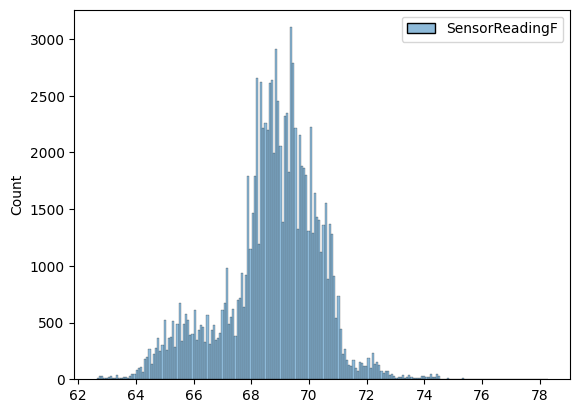

In [15]:
# Histogram of temperature. 
import seaborn
import duckdb
dt = duckdb.sql("""
    SELECT SensorReadingF 
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE SensorReadingF is not null and SensorID_Coris = 21373;
""")
seaborn.histplot(dt.fetchnumpy())

<Axes: xlabel='SensorReadingUTC', ylabel='SensorReadingF'>

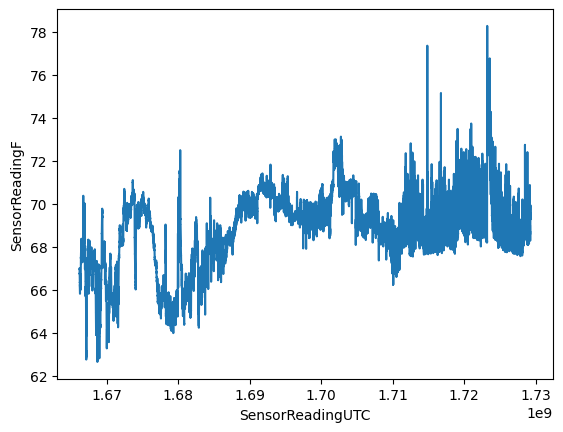

In [16]:
# Time series plot. 
dt = duckdb.sql("""
    SELECT SensorReadingUTC, SensorReadingF 
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE SensorReadingF is not null and SensorID_Coris = 21373;
""")
seaborn.lineplot(x = 'SensorReadingUTC', y= 'SensorReadingF', data=dt.fetchnumpy())

<Axes: xlabel='SensorReadingUTC', ylabel='SensorReadingF'>

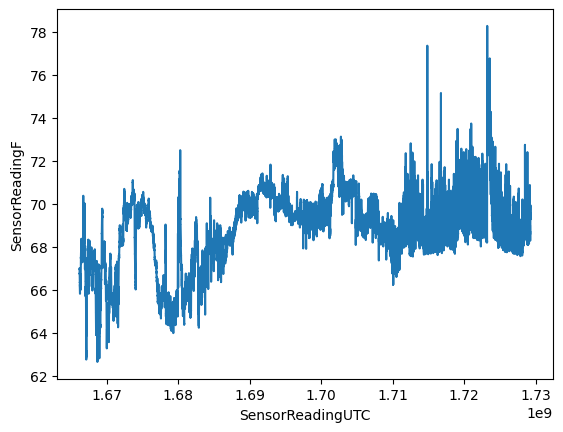

In [17]:
# Time series plot, queried from Devices instead of Sensors. 
# This is the same data, just organized in a different way. 
dt = duckdb.sql("""
    SELECT SensorReadingUTC, SensorReadingF 
    FROM read_parquet('data/device_readings.parquet') 
    WHERE SensorReadingF is not null and DeviceID_Coris = 12162;
""")
seaborn.lineplot(x = 'SensorReadingUTC', y= 'SensorReadingF', data=dt.fetchnumpy())

In [18]:
# Differentiate historical vs. cron readings by filtering on QueryUTC = NULL.
duckdb.sql("""
    SELECT *
    FROM read_parquet('data/device_readings.parquet') 
    WHERE QueryUTC is null
""")

┌────────────────┬───────────────────────────────┬──────────────────┬──────────┬────────────────┬─────────────────┐
│ DeviceID_Coris │          DeviceName           │ SensorReadingUTC │ QueryUTC │ SensorReadingF │ SensorReadingRh │
│     int32      │            varchar            │      int64       │  int32   │     float      │      float      │
├────────────────┼───────────────────────────────┼──────────────────┼──────────┼────────────────┼─────────────────┤
│          12162 │ Peabody TH-L Mammal Hall D444 │       1666204589 │     NULL │          66.97 │            NULL │
│          12162 │ Peabody TH-L Mammal Hall D444 │       1666205189 │     NULL │          67.01 │            NULL │
│          12162 │ Peabody TH-L Mammal Hall D444 │       1666205789 │     NULL │          66.92 │            NULL │
│          12162 │ Peabody TH-L Mammal Hall D444 │       1666206389 │     NULL │          66.97 │            NULL │
│          12162 │ Peabody TH-L Mammal Hall D444 │       1666206989 │   